In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib


import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Titanic\titanic.csv")

In [6]:
print(df.head())

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


In [7]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (418, 12)


In [8]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None


In [9]:
#EDA

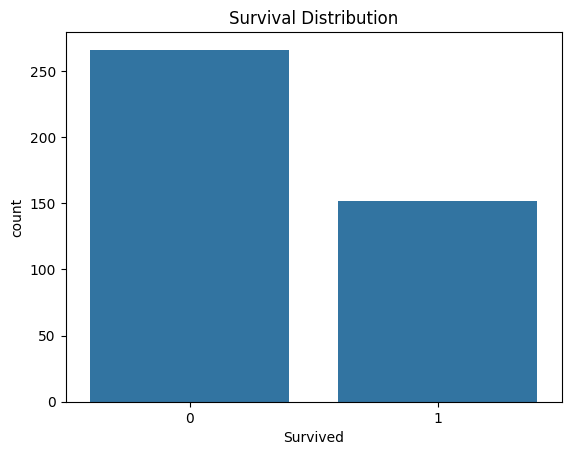

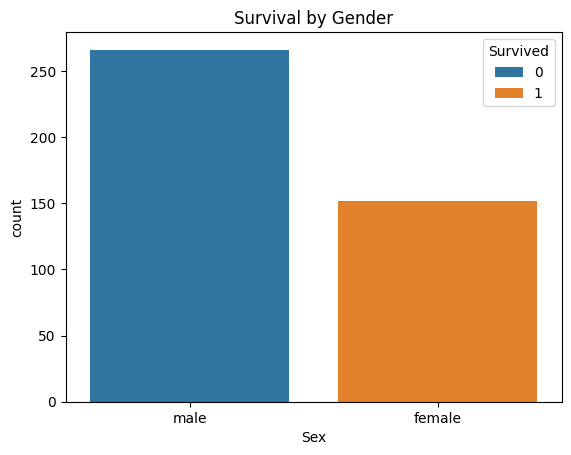

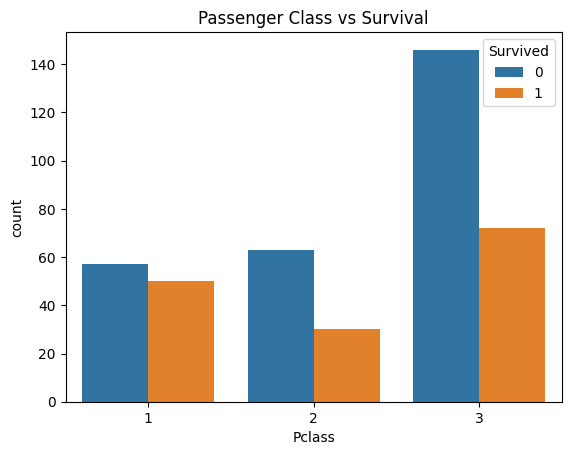

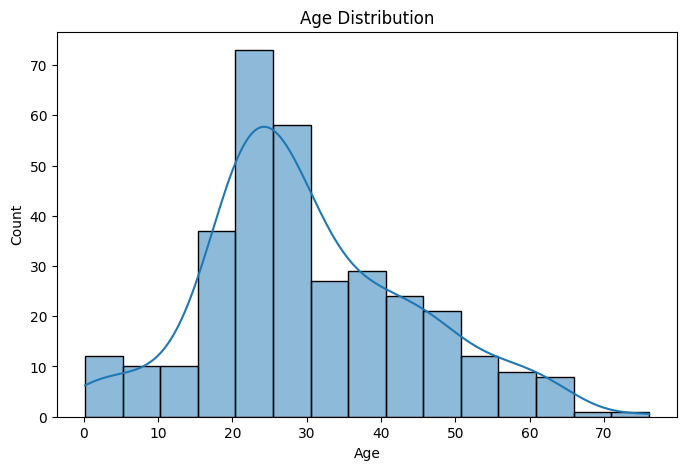

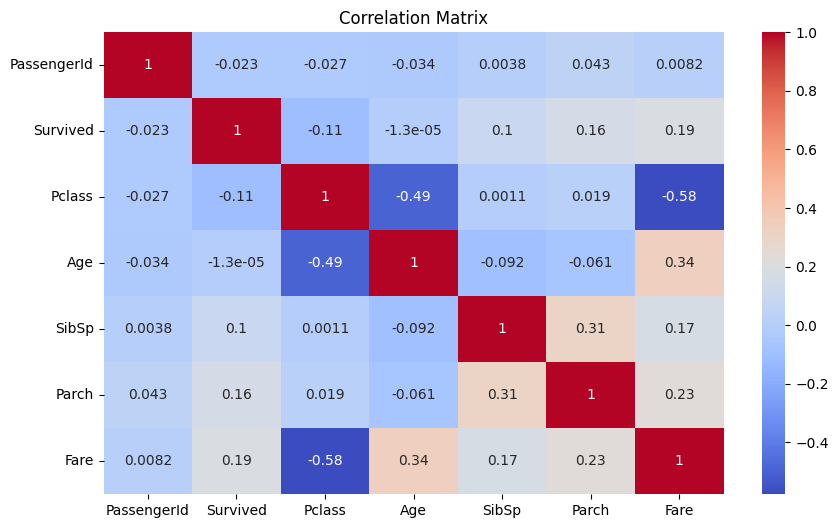

In [10]:
# Survival Distribution
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Passenger Class vs Survival
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
#feature engineering

In [12]:
# Copy dataset
data = df.copy()

# ==========================
# TITLE EXTRACTION
# ==========================
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Replace rare titles
rare_titles = ['Lady', 'Countess','Capt', 'Col',
               'Don', 'Dr', 'Major', 'Rev',
               'Sir', 'Jonkheer', 'Dona']

data['Title'] = data['Title'].replace(rare_titles, 'Rare')
data['Title'] = data['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# FAMILY SIZE
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# IS ALONE FEATURE

data['IsAlone'] = 0
data.loc[data['FamilySize'] == 1, 'IsAlone'] = 1

# CABIN PRESENCE

data['CabinPresent'] = data['Cabin'].notnull().astype(int)

# View Engineered Features
print(data[['Title', 'FamilySize', 'IsAlone', 'CabinPresent']].head())

  Title  FamilySize  IsAlone  CabinPresent
0    Mr           1        1             0
1   Mrs           2        0             0
2    Mr           1        1             0
3    Mr           1        1             0
4   Mrs           3        0             0


In [13]:
#missing value

In [14]:
# Check missing values
print(data.isnull().sum())

# AGE IMPUTATION

# Fill Age using median grouped by Title
data['Age'] = data.groupby('Title')['Age'].transform(
    lambda x: x.fillna(x.median())
)

# ==========================
# EMBARKED IMPUTATION
# ==========================
data['Embarked'] = data['Embarked'].fillna(
    data['Embarked'].mode()[0]
)

# ==========================
# FARE IMPUTATION
# ==========================
data['Fare'] = data['Fare'].fillna(
    data['Fare'].median()
)

# Cabin already handled through CabinPresent
# Drop original Cabin column
data.drop(columns=['Cabin'], inplace=True)

# Verify Missing Values
print("\nRemaining Missing Values:")
print(data.isnull().sum())

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age              86
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin           327
Embarked          0
Title             0
FamilySize        0
IsAlone           0
CabinPresent      0
dtype: int64

Remaining Missing Values:
PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
Title           0
FamilySize      0
IsAlone         0
CabinPresent    0
dtype: int64


In [15]:
# Drop unnecessary columns
data.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Features and Target
X = data.drop('Survived', axis=1)
y = data['Survived']

print("Features:")
print(X.columns)

Features:
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title',
       'FamilySize', 'IsAlone', 'CabinPresent'],
      dtype='object')


In [16]:
# Categorical Columns
categorical_features = ['Sex', 'Embarked', 'Title']

# Numerical Columns
numerical_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone',
    'CabinPresent'
]

# Numerical Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Full Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [17]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (334, 11)
Testing Shape: (84, 11)


In [18]:
# Logistic Regression Pipeline
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Metrics
print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [19]:
# Random Forest Pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Metrics
print("===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [20]:
# XGBoost Pipeline
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Metrics
print("===== XGBoost =====")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

===== XGBoost =====
Accuracy: 1.0

ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



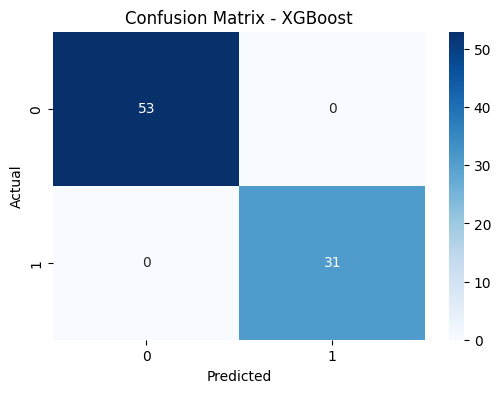

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

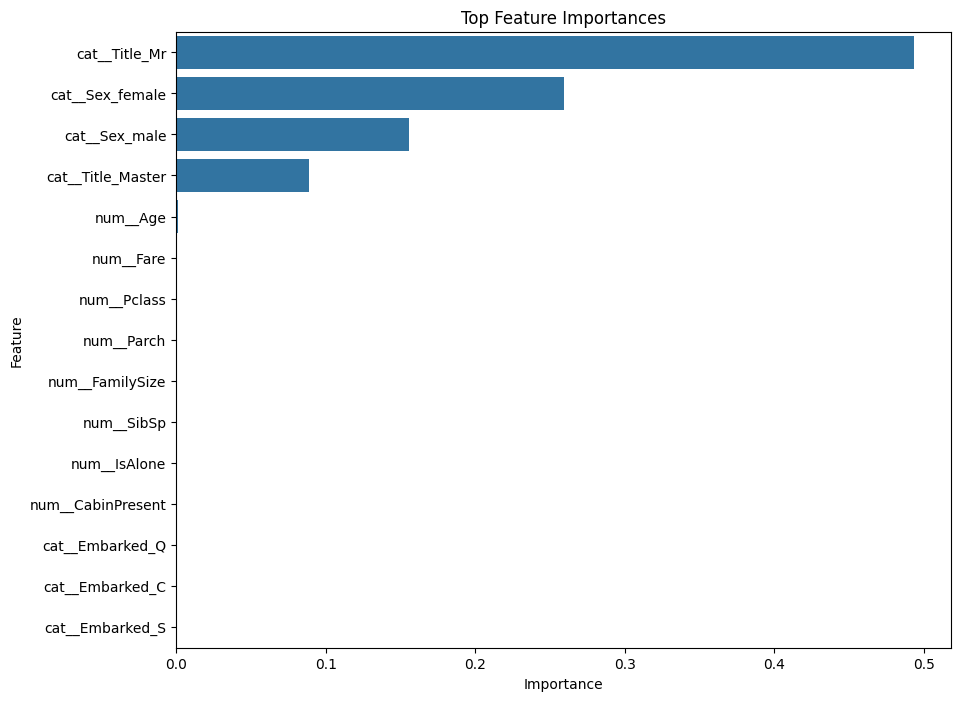

              Feature  Importance
15      cat__Title_Mr    0.493577
8     cat__Sex_female    0.259524
9       cat__Sex_male    0.155794
13  cat__Title_Master    0.089070
1            num__Age    0.001510
4           num__Fare    0.000525
0         num__Pclass    0.000000
3          num__Parch    0.000000
5     num__FamilySize    0.000000
2          num__SibSp    0.000000
6        num__IsAlone    0.000000
7   num__CabinPresent    0.000000
11    cat__Embarked_Q    0.000000
10    cat__Embarked_C    0.000000
12    cat__Embarked_S    0.000000


In [22]:
# Extract trained classifier
model = xgb_model.named_steps['classifier']

# Get feature names after preprocessing
feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()

# Feature Importance
importance = model.feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp.head(15)
)

plt.title("Top Feature Importances")
plt.show()

print(feat_imp.head(15))

In [23]:
# Save Model
joblib.dump(xgb_model, "titanic_survival_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [24]:
# Load Saved Model
loaded_model = joblib.load("titanic_survival_model.pkl")

# Example Passenger
sample_passenger = pd.DataFrame({
    'Pclass': [1],
    'Sex': ['female'],
    'Age': [29],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [100],
    'Embarked': ['C'],
    'Title': ['Miss'],
    'FamilySize': [1],
    'IsAlone': [1],
    'CabinPresent': [1]
})

# Predict
prediction = loaded_model.predict(sample_passenger)

# Probability
probability = loaded_model.predict_proba(sample_passenger)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Passenger Likely Survived")
else:
    print("Passenger Likely Did Not Survive")

print("Survival Probability:", probability[0][1])

Prediction: 1
Passenger Likely Survived
Survival Probability: 0.9905462
